In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp, copyWaveSystem
from argparse import ArgumentParser

import h5py
from dataset import *

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
datasetProperties = DataSetProperties(
    skipInitialSteps= 0,
    skipFinalSteps= 0,
    temporalCoarseGrainingRate= 1,
    unrollLength= 1,
    historyLength= 0
)

simFolder = 'output'
files, S, T, N, Nx, Ny = getDatasetProperties(simFolder)
print(f'Dataset has S={S} samples, T={T} timesteps, N={N} particles, Nx={Nx}, Ny={Ny}')

['waveEqn_128_regular_2026-02-09_13-30-23.h5']
Dataset has S=1 samples, T=1025 timesteps, N=16384 particles, Nx=128, Ny=128


In [4]:
dataset = Dataset(datasetProperties, files, T, device)
batchSize = 1

datasetLoader = torch.utils.data.DataLoader(dataset, batch_size=batchSize, shuffle=False)
datasetIter = iter(datasetLoader)
batch = next(datasetIter)

0it [00:00, ?it/s]

In [5]:
waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(next(datasetIter))



0it [00:00, ?it/s]

0it [00:00, ?it/s]

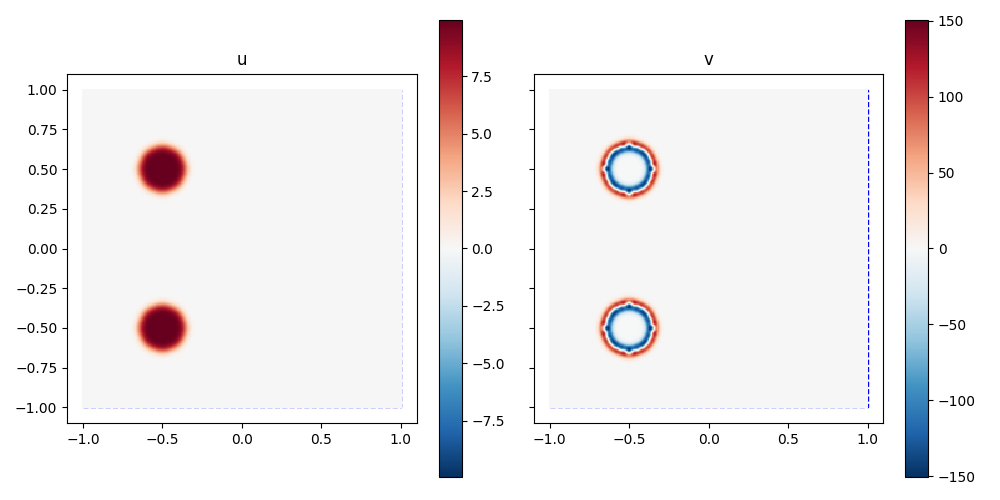

In [6]:
fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    waveSystem.systemState,
    waveSystem.waveState,
    config, config['kernel'],
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
# fig.savefig(f'output/{folderName}/initial_state.png', dpi = args.figureDpi)

In [7]:
particleState = waveSystem.systemState
kernel = config['kernel']

neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries


In [27]:
from ml import *

basisTerms = 5
hiddenLayers = 2
hiddenUnits = 64
nodeFeatures = 16
activation = 'gelu'

additionalEdgeFeatures = 2 # v_i, v_j, h_i, h_j

# neighbors.get('noghost')[1].x_ij

encodedDistances = basisEncoderLayer(
    neighbors.get('noghost')[1].x_ij,
    basisTerms, 
    'ffourier',
    'cat'
)
GNN = SimpleGNN2({
    'hiddenLayers': hiddenLayers,
    'hiddenUnits': hiddenUnits,
    'featureCount': additionalEdgeFeatures,
    'coordinateFeatures': encodedDistances.shape[1],
    'nodeFeatures': nodeFeatures,
    'output': 2,
    'activation': activation,
    'basisTerms': basisTerms,
    'basis': 'ffourier',
    'encoderMode': 'cat',
    'gain': 1/10,
    'messagePassingLayers': 3,
    'finalVertexMLP': True,
}).to(device)


integrator = getIntegrator(IntegrationSchemeType.explicitEuler)
optimizer = torch.optim.Adam(GNN.parameters(), lr=1e-2)
learningRateScheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.75)



In [28]:
import time

data = next(datasetIter)
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

trainIter = 4000
currentUnrollLength = 1
unrollLength = 1
tq = tqdm(total=trainIter, desc='Training', position=0, leave=True)
# sleepTime = 0.1
time.sleep(0.1)
tq2 = tqdm(total=currentUnrollLength, desc='Unroll', position=1, leave=True)

0it [00:00, ?it/s]

Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Unroll:   0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
losses = []
uLosses = []
vLosses = []
for i in range(trainIter):
    if i % 250 == 0 and i > 0:
        currentUnrollLength = min(currentUnrollLength + 1, unrollLength)
        tq2.n = currentUnrollLength
        # print(f'Current unroll length: {currentUnrollLength}')

    optimizer.zero_grad()

    # try:
    #     data = next(datasetIter)
    # except StopIteration:
    #     datasetIter = iter(datasetLoader)
    #     data = next(datasetIter)

    waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(data)


    loss = 0

    waveSystemNext = copyWaveSystem(waveSystem)

    uuLosses = []
    vuLosses = []

    for t in range(currentUnrollLength):
        # waveSystemNext, updates =  eulerIntegrator.function(
        #     waveSystem_,
        #     dt = dt,
        #     f = waveSystemFunction,
        #     verbose = False,
        #     config = config,
        # )
        waveSystemNext = copyWaveSystem(waveSystemNext)

        features = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
        ], dim=-1)

        fi_nn = GNN(waveSystemNext.systemState, waveSystemNext.neighborhood, features)

        dudt = fi_nn[:, 0]
        dvdt = fi_nn[:, 1]

        # print(f'Max dudt: {torch.max(dudt)}, Max dvdt: {torch.max(dvdt)}')
        # print(f'Requires Gradient: dudt {dudt.requires_grad}, dvdt {dvdt.requires_grad}')

        waveSystemNext.waveState.u = waveSystemNext.waveState.u + dudt
        waveSystemNext.waveState.v = waveSystemNext.waveState.v + dvdt

        uLoss = torch.mean((waveSystemNext.waveState.u - trajectory[t,:,0])**2)
        vLoss = torch.mean((waveSystemNext.waveState.v - trajectory[t,:,1])**2)

        uuLosses.append(uLoss)
        vuLosses.append(vLoss)

        # print(f'Iter {i}, uLoss: {uLoss} [type: {type(uLoss)}], vLoss: {vLoss}')
        # print(uLoss)
        # print(vLoss)

    uuLosses = torch.stack(uuLosses)
    vuLosses = torch.stack(vuLosses)

    uLossTotal = sum(uuLosses) / len(uuLosses)
    vLossTotal = sum(vuLosses) / len(vuLosses)

    # print(uLossTotal, vLossTotal)

    totalLoss = uLossTotal + vLossTotal
    # print(f'Total Loss:' , totalLoss)
    totalLoss.backward()
    optimizer.step()
    learningRateScheduler.step()

    losses.append(totalLoss.item())
    uLosses.append(uLossTotal)
    vLosses.append(vLossTotal)
    tq.set_postfix({'loss': totalLoss.detach().item(), 'uLoss': uLossTotal.detach().item(), 'vLoss': vLossTotal.detach().item(), 'lr': learningRateScheduler.get_last_lr()[0]})
    tq.update()


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

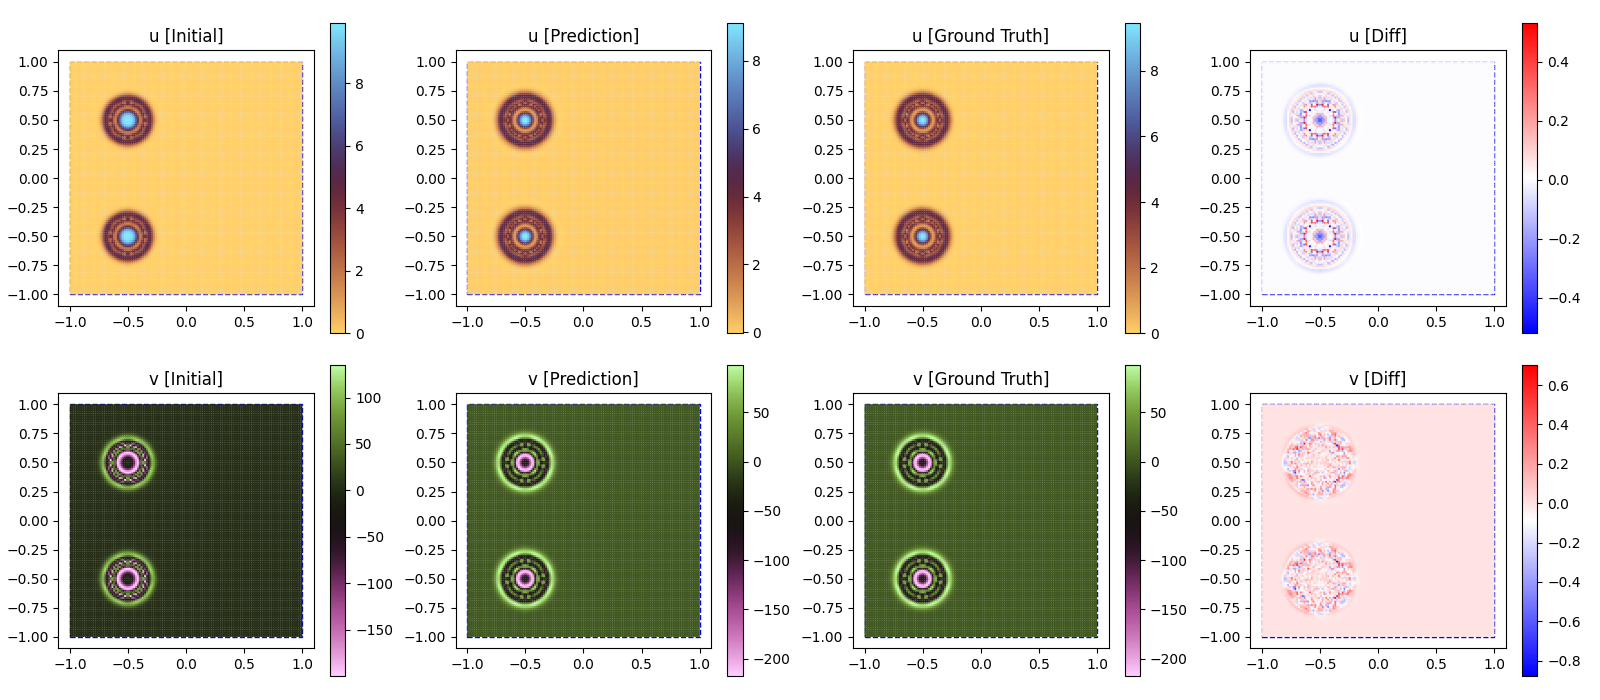

In [30]:
fig, axis = plt.subplots(2,4, figsize=(16, 7), squeeze=False)

markerSize = 0.5

uInitial = visualizeParticles(fig, axis[0,0], waveSystem.systemState, config['domain'], waveSystem.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Initial]')
vInitial = visualizeParticles(fig, axis[1,0], waveSystem.systemState, config['domain'], waveSystem.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Initial]')

uPlotRk4 = visualizeParticles(fig, axis[0,1], waveSystem.systemState, config['domain'], waveSystemNext.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Prediction]')
vPlotRk4 = visualizeParticles(fig, axis[1,1], waveSystem.systemState, config['domain'], waveSystemNext.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Prediction]')


uDiff = waveSystem.waveState.u - trajectory[0,:,0]
vDiff = waveSystem.waveState.v - trajectory[0,:,1]

uDiff = trajectory[0,:,0]
vDiff = trajectory[0,:,1]

uPlotGT = visualizeParticles(fig, axis[0,2], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Ground Truth]')
vPlotGT = visualizeParticles(fig, axis[1,2], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Ground Truth]')

diffU = (waveSystemNext.waveState.u - trajectory[0,:,0])#.detach().cpu().numpy()
diffV = (waveSystemNext.waveState.v - trajectory[0,:,1])#.detach().cpu().numpy()

visualizeParticles(fig, axis[0,3], waveSystem.systemState, config['domain'], diffU, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'bwr', markerSize = markerSize, gridVisualization = False, title = 'u [Diff]')
visualizeParticles(fig, axis[1,3], waveSystem.systemState, config['domain'], diffV, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'bwr', markerSize = markerSize, gridVisualization = False, title = 'v [Diff]')


fig.tight_layout()


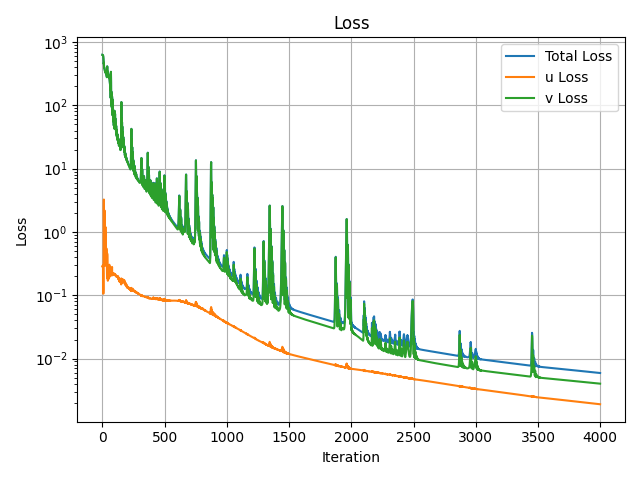

In [31]:
fig, axis = plt.subplots(1, 1)
axis.plot(losses, label='Total Loss')
axis.plot([u.detach().cpu().item() for u in uLosses], label='u Loss')
axis.plot([v.detach().cpu().item() for v in vLosses], label='v Loss')
axis.set_yscale('log')
axis.set_title('Loss')
axis.set_xlabel('Iteration')
axis.set_ylabel('Loss')
axis.grid(True)
axis.legend()

fig.tight_layout()

In [8]:
u = waveSystem.waveState.u
v = waveSystem.waveState.v
c = waveSystem.waveState.c
damp = waveSystem.waveState.damping

# u.requires_grad = True
# v.requires_grad = True

waveSystem.waveState.u = u
waveSystem.waveState.v = v
waveSystem.waveState.c = c
waveSystem.waveState.damping = damp

In [9]:
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

In [10]:
waveSystemNext, updates =  eulerIntegrator.function(
    waveSystem,
    dt = dt,
    f = waveSystemFunction,
    verbose = False,
    config = config,
)

In [12]:
# simResultU = waveSystemNext.waveState.u

# print(f'waveSystemNext.waveState.u shape: {simResultU.shape}, dtype: {simResultU.dtype}, device: {simResultU.device}')
# print(f'Value: {simResultU}')

# loss = torch.nn.MSELoss()(simResultU, trajectory[0,:,0])
# print(f'Loss: {loss.item()}')

# loss.backward()

In [13]:
simResultU = waveSystemNext.waveState.u.shape
trajectoryU = trajectory[0,:,0]

print(f'waveSystemNext.waveState.u shape: {simResultU}')
print(f'trajectoryU shape: {trajectoryU.shape}')
print(f'close: {torch.allclose(waveSystemNext.waveState.u.cpu(), trajectory[0,:,0].cpu(), atol=1e-5)}')

waveSystemNext.waveState.u shape: torch.Size([16384])
trajectoryU shape: torch.Size([16384])
close: False


In [14]:
n = waveSystem.waveState.u.shape[0]
nx = int(n**0.5)
print(f'Assuming square grid with nx={nx}, ny={nx}')
domainArea = (config['domain'].max[0] - config['domain'].min[0]) * (config['domain'].max[1] - config['domain'].min[1])
print(f'Particle area: {domainArea/n}, particle spacing: {(domainArea/n)**0.5}')
dx = (domainArea/n)**0.5


Assuming square grid with nx=128, ny=128
Particle area: 0.000244140625, particle spacing: 0.015625


In [ ]:

waveSystemEuler = copyWaveSystem(waveSystem)
waveSystemRK4 = copyWaveSystem(waveSystem)

for i in range(1):
    waveSystemEuler, updates =  eulerIntegrator.function(
        waveSystemEuler,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )
    waveSystemRK4, updates = RK4Integrator.function(
        waveSystemEuler,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )

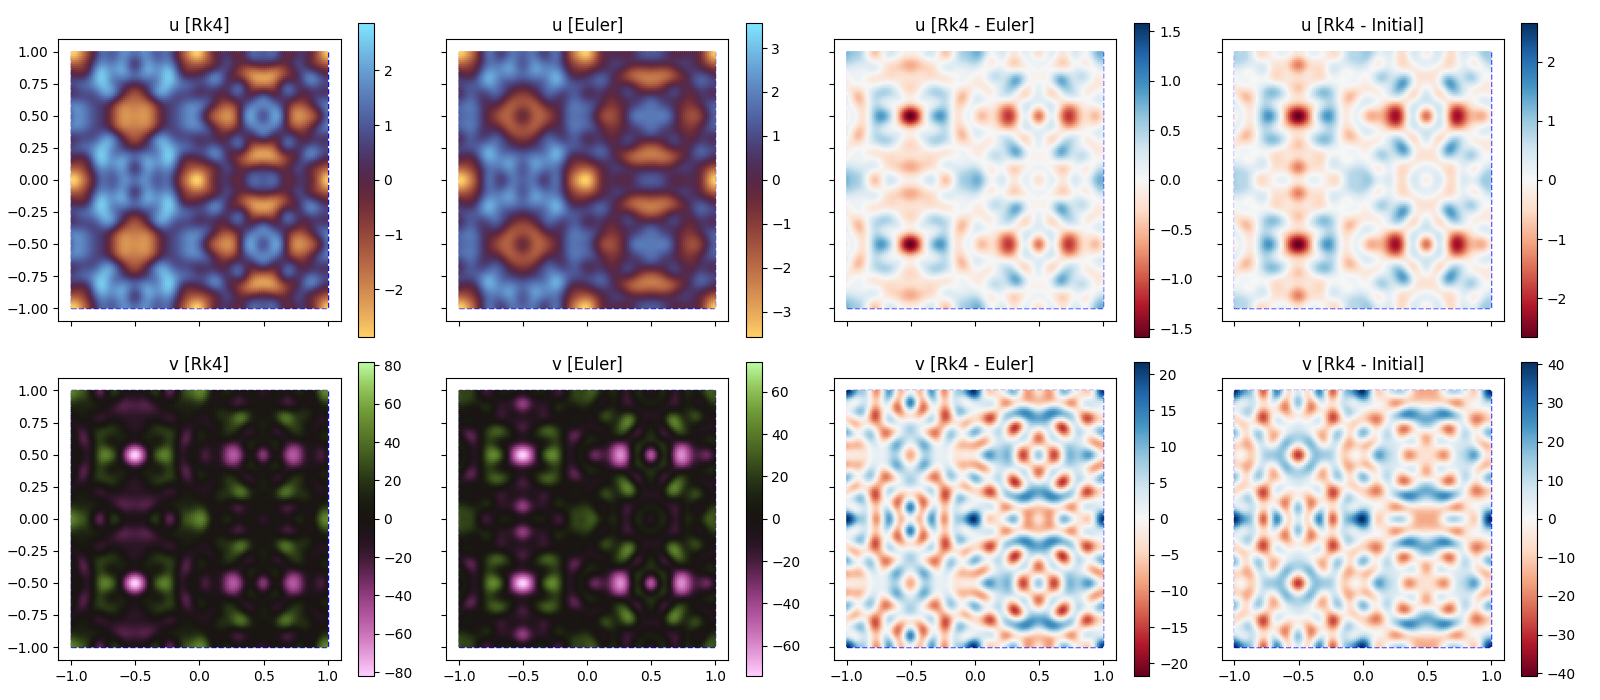

In [18]:
fig, axis = plt.subplots(2, 4, figsize=(16,7), sharex=True, sharey=True)

markerSize = 1.5

uMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.u)).cpu().detach().item()
vMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.v)).cpu().detach().item()

uPlotRk4 = visualizeParticles(fig, axis[0,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4]', vmin = -uMaxRk4, vmax = uMaxRk4)
vPlotRk4 = visualizeParticles(fig, axis[1,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4]', vmin = -vMaxRk4, vmax = vMaxRk4)


umaxEuler = torch.max(torch.abs(waveSystemEuler.waveState.u)).cpu().detach().item()
vmaxEuler = torch.max(torch.abs(waveSystemEuler.waveState.v)).cpu().detach().item()

uPlotEuler = visualizeParticles(fig, axis[0,1], waveSystem.systemState, config['domain'], waveSystemEuler.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Euler]', vmin = -umaxEuler, vmax = umaxEuler)
vPlotEuler = visualizeParticles(fig, axis[1,1], waveSystem.systemState, config['domain'], waveSystemEuler.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Euler]', vmin = -vmaxEuler, vmax = vmaxEuler)

uDiff = (waveSystemRK4.waveState.u - waveSystemEuler.waveState.u)
vDiff = (waveSystemRK4.waveState.v - waveSystemEuler.waveState.v)

uDiffVmax = torch.max(torch.abs(uDiff)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiff)).cpu().detach().item()

uPlotDiff = visualizeParticles(fig, axis[0,2], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4 - Euler]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiff = visualizeParticles(fig, axis[1,2], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4 - Euler]', vmin = -vDiffVmax, vmax = vDiffVmax)

uDiff = (waveSystemRK4.waveState.u - waveSystem.waveState.u)
vDiff = (waveSystemRK4.waveState.v - waveSystem.waveState.v)

uDiffVmax = torch.max(torch.abs(uDiff)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiff)).cpu().detach().item()

uPlotDiffInitial = visualizeParticles(fig, axis[0,3], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4 - Initial]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiffInitial = visualizeParticles(fig, axis[1,3], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4 - Initial]', vmin = -vDiffVmax, vmax = vDiffVmax)


fig.tight_layout()